
> **Course: AIML ZG528 AI and ML for Robotics**

>  **Author: Raja vadhana Prabhakar**
raja.vadhana@pilani.bits-pilani.ac.in

> **Objective:**
To implement AIML technique to optimize few components of the traditional localization algorithm.
Below include FOUR DISTINCT usecases which is designed in this lab sheet to compliment existing traditional algorithms.

>>> **Usecase 1**: Camera fed erroneous sensor data is denoised using autoencoder. The ouput of this is fed to the measurement model before correction step in localization.

>>> **Usecase 2**: In grid based localization, determine the coarseness(Resolution) of the grid based on uncertainties observed in dynamic environment using Q-Learning.

>>> **Usecase 3**: In Montecarlo localization resampling step, dynamically weigh the particles based on its  sensor reliability categorization using Random Forest Classifier.

>>> **Usecase 4**: Dynamic resampling scheduler with particle's measurement observation using Multi Armed Bandit algorithm.

Note: Alternatively the entire traditional localization pipeline can be replaced by ML/ DNN/ DRL models. The key is in data availabilty & readiness.

In [ ]:
!pip -q install torch torchvision

# 1. Localization : Preprocessing
> Input : Noisy Sensor data |

> Output : Clean Sensor data
>> Idea : Use denoising Autoencoder
>>> How to add in phases of Robotics : Before measurement model is applied in the correction step of localization , the input images of the surroundings can be processed using this to get clean sensor data. Post which optional object(landmark) identification tasks can be done for calulating P(Z|X)

In [ ]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

In [ ]:
# Synthetic dataset is designed in below code: clean maps with edges + noise.
# Students must Replace this section with actual images of clean map vs noisy map with landmarks/objects for training
class DenoiseMaps(Dataset):
    def __init__(self, n=2000, size=64, noise_std=0.2):
        self.X, self.Y = [], []
        rng = np.random.RandomState(42)
        for _ in range(n):
            img = np.zeros((size, size), dtype=np.float32)
            # random rectangles/lines to mimic structure
            for _ in range(rng.randint(2,6)):
                x1,y1 = rng.randint(0,size-10,2)
                w,h = rng.randint(5,20,2)
                img[y1:y1+h, x1:x1+w] = 1.0
            clean = img
            noisy = clean + rng.normal(0, noise_std, clean.shape).astype(np.float32)
            noisy = np.clip(noisy, 0, 1)
            self.X.append(noisy[None, ...])   # 1xHxW
            self.Y.append(clean[None, ...])
        self.X = torch.tensor(np.stack(self.X))
        self.Y = torch.tensor(np.stack(self.Y))

    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]

In [ ]:
train_ds = DenoiseMaps(n=1500)
val_ds   = DenoiseMaps(n=200)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=32)

In [ ]:
# Simple CNN (very small).
#Students must try to tune this architecture by increasing depth, using skip connections to connect encoder layers to decoder to reduce loss of information
class SmallUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1), nn.ReLU(),
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(64,32,2,stride=2), nn.ReLU(),
            nn.ConvTranspose2d(32,16,2,stride=2), nn.ReLU(),
            nn.Conv2d(16,1,3,padding=1), nn.Sigmoid()
        )
    def forward(self,x):
        z = self.enc(x)
        out = self.dec(z)
        return out

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SmallUNet().to(device)
opt   = optim.Adam(model.parameters(), lr=1e-3)
lossf = nn.MSELoss()

In [ ]:
def eval_dl(dl):
    model.eval()
    l = 0
    with torch.no_grad():
        for xb,yb in dl:
            xb,yb = xb.to(device), yb.to(device)
            l += lossf(model(xb), yb).item()*len(xb)
    return l/len(dl.dataset)

In [ ]:
for epoch in range(10):
    model.train()
    for xb,yb in train_dl:
        xb,yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        pred = model(xb)
        loss = lossf(pred,yb)
        loss.backward(); opt.step()
    print(f"Epoch {epoch+1:02d} | val MSE: {eval_dl(val_dl):.4f}")

Epoch 01 | val MSE: 0.0213
Epoch 02 | val MSE: 0.0072
Epoch 03 | val MSE: 0.0032
Epoch 04 | val MSE: 0.0021
Epoch 05 | val MSE: 0.0016
Epoch 06 | val MSE: 0.0013
Epoch 07 | val MSE: 0.0011
Epoch 08 | val MSE: 0.0010
Epoch 09 | val MSE: 0.0009
Epoch 10 | val MSE: 0.0009


In [ ]:
# Example inference on one sample
x_test, y_test = val_ds[0]
with torch.no_grad():
    pred = model(x_test[None].to(device)).cpu().squeeze(0).squeeze(0).numpy()
print("One sample: noisy/clean/pred shapes:", x_test.shape, y_test.shape, pred.shape)

One sample: noisy/clean/pred shapes: torch.Size([1, 64, 64]) torch.Size([1, 64, 64]) (64, 64)


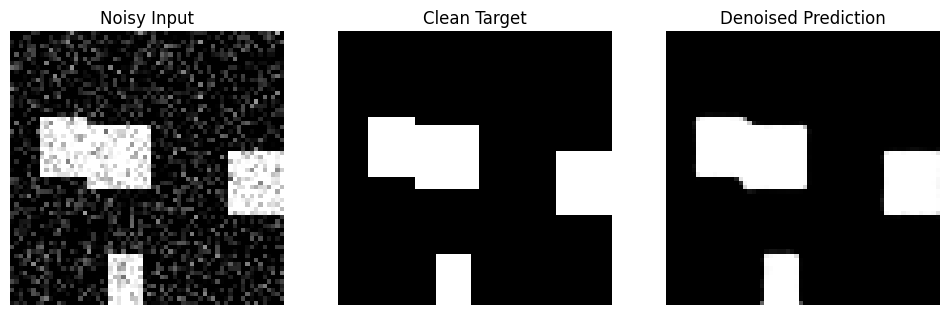

In [ ]:
import matplotlib.pyplot as plt

# Example inference on one sample
x_test, y_test = val_ds[0]
with torch.no_grad():
    pred = model(x_test[None].to(device)).cpu().squeeze(0).squeeze(0).numpy()

# Convert tensors to numpy arrays for visualization
noisy_img = x_test.squeeze(0).numpy()
clean_img = y_test.squeeze(0).numpy()

# Plot side by side
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(noisy_img, cmap='gray')
axs[0].set_title("Noisy Input")
axs[0].axis('off')

axs[1].imshow(clean_img, cmap='gray')
axs[1].set_title("Clean Target")
axs[1].axis('off')

axs[2].imshow(pred, cmap='gray')
axs[2].set_title("Denoised Prediction")
axs[2].axis('off')

plt.show()


# 2. Localization : Dynamic Grid Resolution (in Grid Loc) , Dynamic Particle Sampling (in MonteCarlo Loc)
> Input State : Info abt Tasks Categorization & Uncertainity at timestep(t)  Eg.,[Category is HighPrecisionNeededTask , Uncertainty=Low ]|

> Output Action : Recommendation on necessary resolution/level/No.of.Particles eg., [CoarseResolution] or [LessNoofParticles] vs [FineResolution] or [MoreNoofParticles].

*Below code depicts only for Grid. Students might change it for Particle filter*

>>> Idea : Use Reinforcement Learner to decide level of redesign(resolution/Particle size required)
>>>> Where to add in phases of Robotics : After estimation of pose Xt (Predict & Correct step) check if environment / Robot hardware changes drastically. If so trigger RL to learn before proceeding with grid use/resampling for estimating next iteration for predicting X(t+1) . Alternatively if its static env, set some frequency eg., once in a week or months for retraining the agent

In [ ]:
import numpy as np

In [ ]:
# States: task precision need (0=low,1=medium,2=high), uncertainty (0=low,1=high)
states = [(p,u) for p in range(3) for u in range(2)]
state_idx = {s:i for i,s in enumerate(states)}
# Actions: 0=coarse, 1=medium, 2=fine resolution
A = [0,1,2]

Reward function: balance accuracy vs compute cost
> Dummy reward as a function of state & action is hardcoded below. Eg., Peanlizes low resolution , high compute action choices. If reward function can be modelled , then replace using that.

In [ ]:
def simulate_step(state, action):
    p,u = state
    acc = (action+1) * (p+1)
    acc -= (2 if (u==1 and action==0) else 0)
    cost = (action) * 2
    reward = acc - cost

    # next state randomly varies uncertainty. If the there is a model dynamics P(X`,r | X,a) use it instead of randomization
    next_state = (p, np.random.choice([0,1], p=[0.6,0.4]))
    done = False
    return next_state, reward, done

In [ ]:
Q = np.zeros((len(states), len(A)))
alpha, gamma, eps = 0.2, 0.95, 0.2
episodes = 5000

In [ ]:
for ep in range(episodes):
    s = (np.random.choice([0,1,2]), np.random.choice([0,1]))
    for t in range(10):
        si = state_idx[s]
        if np.random.rand() < eps:
            a = np.random.choice(A)
        else:
            a = np.argmax(Q[si])
        ns, r, d = simulate_step(s, a)
        nsi = state_idx[ns]
        Q[si, a] += alpha * (r + gamma * np.max(Q[nsi]) - Q[si, a])
        s = ns
        if d: break

In [ ]:
print("Learned Q-values (rows=states p,u; cols=actions coarse/med/fine):\n", Q.round(2))
# Policy: choose resolution per state
policy = {s: ['coarse','medium','fine'][np.argmax(Q[state_idx[s]])] for s in states}
print("Adaptive resolution policy:", policy)

Learned Q-values (rows=states p,u; cols=actions coarse/med/fine):
 [[ 12.6   11.56  10.28]
 [ 10.39  11.04   9.98]
 [ 40.    40.    40.  ]
 [ 38.    40.    40.  ]
 [ 98.    99.   100.  ]
 [ 96.    99.   100.  ]]
Adaptive resolution policy: {(0, 0): 'coarse', (0, 1): 'medium', (1, 0): 'coarse', (1, 1): 'medium', (2, 0): 'fine', (2, 1): 'fine'}


# 3. Localization : Dynamic weighing of Particles for resampling using sensor relability
> Input : Sensor Readings w.r.t each particle Poses ie., Measurement Zei per particle Xi

> Output : adjusted weights per Particles Xi
>>> Idea : Use ensemble learners for prediction of reliability score per particle. This is possible only if supervised input is available
>>>> Where to add in phases of Robotics : After estimation of pose Xt in Predict step ie., motion model in the Correct step ie., in Measurement model apply this for particle set (all M).

In [ ]:
!pip -q install scikit-learn

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [ ]:
# Students must replace this entire section with actual observed supervised(labelled) sensor data for training the classifier
rng = np.random.RandomState(1)
N = 4000
# Dummy values for sample Features: signal strength, drift, temperature, vibration
X = np.column_stack([
    rng.uniform(0,1,N),
    rng.normal(0,1,N),
    rng.uniform(20,40,N),
    rng.uniform(0,5,N)
])
# Hardcoded logic for Labelling every instance: reliable if strength high, drift low, temperature moderate, vibration low
y = ((X[:,0] > 0.4) & (np.abs(X[:,1]) < 0.8) & (X[:,2] < 35) & (X[:,3] < 3)).astype(int)

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X, y)
print(classification_report(y, rf.predict(X)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3378
           1       1.00      1.00      1.00       622

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [ ]:
num_particles = 10
weights = np.ones(num_particles)/num_particles
feat = np.array([0.3, 1.2, 38, 4.0])  #This is dummy sensor readings/features for current step for only one particle. Students must replace this with actual observed readings
proba_reliable = rf.predict_proba(feat.reshape(1,-1))[0,1]
print("Predicted reliability:", proba_reliable)

Predicted reliability: 0.0


In [ ]:
# Weight adjustment logic. In below random particles & random sensor measurement is simulated. Students must replace this with actual data
# If the normalized weights of all particles are almost same with high probability score, then particle diversity is observed and realibility is good.
# If the normalized weights of all particles are almost same with Low/medium probability score, then particle diversity is observed but realibility is Low/medium
# If the normalized weights are varying with one particle having all weights(high) compared to others,then particle degeneracy is observed (which may tell us that more random resampling might be required) and realibility is good for that one particle hence its weighed more(or retained during next step) but over all sensor may have been unreliable across all the particle's observation!!
measurement_likelihood = np.random.rand(num_particles)
print("Weights of all 10 particles before measurement",weights)
adjusted_likelihood = measurement_likelihood * (0.5 + 0.5*proba_reliable)
weights *= adjusted_likelihood
weights /= weights.sum()
print("Weights of all 10 particles after measurement",weights)
print("Score before/after:",
      1.0/np.sum((np.ones(num_particles)/num_particles)**2),
      1.0/np.sum(weights**2))

Weights of all 10 particles before measurement [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Weights of all 10 particles after measurement [0.11274834 0.10923723 0.03387718 0.14632055 0.00709775 0.16578753
 0.09925144 0.14543018 0.04778971 0.13246008]
Score before/after: 9.999999999999996 7.963778976020219


# 4. Localization : Dynamic resampling schedule using particle's measurement observation
> Input : Localization accuracy observed at previous step (t-1), Threshold ESS used in previous step (t-1), Bel Xi per particle Xi at current step (t-1)

> Output : Best ESS Threshold
>>> Idea : Use Multiarmed bandit with reward = f(localization accuracy, resampling cost) and action space = {Threshold1, Threshold2,....}
>>>> Where to add in phases of Robotics : After entire one interation of localization ie., estimation of pose Xt using aggregation from resampled set M is obtained, call MAB which revises the Q(ThresholdUsedat t-1) . Then recommends next best ESS threshold to set ie., when to next resampling.

In [ ]:
import numpy as np

In [ ]:
# Simulate particle weights evolution and resampling effect
def simulate_episode(threshold_choice):
    # thresholds: 0=low(ESS trigger easy),1=med,2=high(harder to resample)
    thresholds = [0.3, 0.5, 0.7]
    th = thresholds[threshold_choice]
    rng = np.random.RandomState()
    reward = 0
    N = 200 #No.of.Particles
    weights = np.ones(N)/N
    for t in range(20):
        # measurement update: random multiplicative noise
        update = rng.lognormal(mean=0, sigma=0.6, size=N) #Substitute this with actual measurement readings
        weights *= update
        weights /= weights.sum()
        ESS = 1.0 / np.sum(weights**2)
        # reward encourages moderate ESS (avoid depletion but not over-resampling)
        reward += -abs(ESS/N - 0.5)  # best near 0.5 of N
        if ESS/N < th:
            # resample (systematic)
            cdf = np.cumsum(weights)
            u0 = rng.rand()/N
            idx = []
            for i in range(N):
                u = u0 + i/N
                idx.append(np.searchsorted(cdf, u))
            weights = np.ones(N)/N
            reward -= 0.05  # small cost for resampling
    return reward

In [ ]:
# Q-learning in a stateless bandit (choose threshold policy)
Q = np.zeros(3)
alpha, eps = 0.1, 0.2
for ep in range(2000):
    a = np.random.choice(3) if np.random.rand()<eps else np.argmax(Q)
    r = simulate_episode(a) #This is obtained from random simulation of events.
    #In reality this is a cummulative reward obtained per unique threshold
    #eg., Out of 10 steps of locomotion, agent would have used 0.3 as threshold in 4 steps
    #and among those four steps only 3 steps trigerred resampling.
    #Hence lets add -5 as penatly per resampling in these 3 steps and +2 as reward in that one step where resampling was not done . Then Q(0.3)= (3(-5)+2)/ 4 = -3.25. Note : This assumes undiscounted value estimation
    Q[a] += alpha*(r - Q[a])

In [ ]:
print("Estimated value per threshold (low/med/high):", Q.round(3))
best = np.argmax(Q)
print("Best resampling threshold choice:", ["low","medium","high"][best])

Estimated value per threshold (low/med/high): [-3.334 -2.833 -3.625]
Best resampling threshold choice: medium


## Exercises
1. Run the Traditional localization algorithm and collect data
2. Curate the necessary datasets/reward designs from EDA on the collected data.
3. Use the data/reward distribution to Integrate respective above solutions seperately to train the models
4. Integrated the models into the traditional localization algorithm. Observe the results.
